# A3: Predicting Car Price (Classification)

What this notebook covers:

1. **Task 1:** a multinomial logistic regression class (based on the class notebook) with accuracy, precision, recall, F1, macro and weighted averages written from scratch, checked against sklearn.
2. **Task 2:** an optional Ridge (L2) penalty in the same class.
3. **Task 3:** experiments logged with MLflow, the best model registered and moved to Staging, and a CI/CD pipeline on GitHub Actions that tests the model and deploys the web app.


## Setup

In [35]:
import os
import sys
import pickle
import importlib
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report

np.random.seed(42)

# The class is written to app/code/model.py (section 9) so the web app and tests can import it
os.makedirs("app/code/model", exist_ok=True)
sys.path.insert(0, "app/code")

## 1. Load and clean (carried over from A1, unchanged)

In [36]:
df = pd.read_csv("Cars.csv")

# Duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Fuel: keep Diesel/Petrol only (CNG/LPG use a different mileage unit)
df = df[df["fuel"].isin(["Diesel", "Petrol"])].reset_index(drop=True)

# Owner: map to 1-5, then drop Test Drive Car rows
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5,
}
df["owner"] = df["owner"].map(owner_mapping)
df = df[df["owner"] != 5].reset_index(drop=True)

# Strip units from mileage / engine / max_power
df["mileage"] = pd.to_numeric(df["mileage"].astype(str).str.split(" ").str[0], errors="coerce")
df["engine"] = pd.to_numeric(df["engine"].astype(str).str.split(" ").str[0], errors="coerce")
df["max_power"] = pd.to_numeric(df["max_power"].astype(str).str.split(" ").str[0], errors="coerce")

# Brand = first word of name
df["brand"] = df["name"].astype(str).str.split(" ").str[0]

df = df.drop(columns=["name", "torque"])
df.shape

(6827, 12)

## 2. Target: bucket selling_price into 4 classes

**Choice: `pd.qcut()` (quantile bins), not `pd.cut()` (equal-width bins).**

A1's EDA showed `selling_price` is strongly right-skewed (skewness ≈ 1.87). Equal-width bins would put most cars in class 0 and leave very few in class 3, so a model could score well just by predicting "cheap". Quantile bins give each class about 25% of the cars, so accuracy and macro scores stay meaningful. The trade-off is that the price ranges differ in width (class 3 covers a much wider range than class 0).

`retbins=True` keeps the bin edges so the web app can show the price range of each class.

In [37]:
df["price_class"], price_bins = pd.qcut(df["selling_price"], q=4, labels=[0, 1, 2, 3], retbins=True)
df["price_class"] = df["price_class"].astype(int)

print("Price range of each class:")
for c in range(4):
    print(f"  class {c}: {price_bins[c]:>12,.0f}  to {price_bins[c+1]:>12,.0f}")

df["price_class"].value_counts().sort_index()

Price range of each class:
  class 0:       29,999  to      250,000
  class 1:      250,000  to      409,999
  class 2:      409,999  to      640,000
  class 3:      640,000  to   10,000,000


price_class
0    1846
1    1583
2    1697
3    1701
Name: count, dtype: int64

## 3. Train/test split

In [38]:
X = df.drop(columns=["selling_price", "price_class"])
y = df["price_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((5461, 11), (1366, 11))

## 4. Missing values (median imputation, fitted on the training set only, same as A2)

In [39]:
numeric_cols = ["year", "km_driven", "mileage", "engine", "max_power", "seats", "owner"]

for col in numeric_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

## 5. One-hot encode categoricals, with one baseline column dropped

In A2, keeping every dummy column meant the dummies in each group always added up to 1, so their coefficients could not be pinned down (the dummy variable trap). Here I drop one baseline category per group from the start.

In [40]:
categorical_cols = ["fuel", "seller_type", "transmission", "brand"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[categorical_cols])

train_encoded = pd.DataFrame(
    encoder.transform(X_train[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index,
)
test_encoded = pd.DataFrame(
    encoder.transform(X_test[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index,
)

X_train_final = pd.concat([X_train.drop(columns=categorical_cols), train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), test_encoded], axis=1)

# Drop one baseline dummy per categorical group (the most frequent category in each)
drop_cols = ["fuel_Petrol", "transmission_Manual", "seller_type_Individual", "brand_Maruti"]
X_train_final = X_train_final.drop(columns=drop_cols, errors="ignore")
X_test_final = X_test_final.drop(columns=drop_cols, errors="ignore")

feature_names = X_train_final.columns.tolist()
len(feature_names)

41

## 6. Scale numeric features (fitted on the training set only, same as A2)

In [41]:
scaler = StandardScaler()
X_train_final[numeric_cols] = scaler.fit_transform(X_train_final[numeric_cols])
X_test_final[numeric_cols] = scaler.transform(X_test_final[numeric_cols])

## 7. Add intercept, convert to numpy (matches 02's expected input shape)

In [42]:
X_train_np = X_train_final.to_numpy()
X_test_np = X_test_final.to_numpy()

intercept_train = np.ones((X_train_np.shape[0], 1))
X_train_final_np = np.concatenate((intercept_train, X_train_np), axis=1)

intercept_test = np.ones((X_test_np.shape[0], 1))
X_test_final_np = np.concatenate((intercept_test, X_test_np), axis=1)

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

X_train_final_np.shape, X_test_final_np.shape

((5461, 42), (1366, 42))

## 8. One-hot encode y for training (matches 02's Y shape of (m, k))

In [43]:
k = len(np.unique(y_train_np))   # number of classes
m = X_train_final_np.shape[0]
n = X_train_final_np.shape[1]

Y_train_encoded = np.zeros((m, k))
for each_class in range(k):
    Y_train_encoded[np.where(y_train_np == each_class), each_class] = 1

k, m, n

(4, 5461, 42)

## 9. The LogisticRegression class

I started from the class in `02 - Multinomial Logistic Regression.ipynb` and made these changes:

| Change | Reason |
| --- | --- |
| `accuracy`, per-class `precision`, `recall`, `f1_score`, `support`, the `macro_*` and `weighted_*` versions, and `classification_report` | Task 1: classification metrics written from scratch |
| `penalty=None` or `"ridge"`, with strength `lambda_` | Task 2: optional L2 penalty that does not touch the intercept row |
| Softmax subtracts the row maximum, and the loss uses `log(h + 1e-12)` | stops `exp()` from overflowing and `log(0)` from giving `nan` when the learning rate is large |
| `random_state` and `verbose` | same starting weights in every run, and no printing during the 27 experiment runs |
| Stochastic loop checks `idx` instead of `i` | the original loop could pick the same row again before every row had been used |
| `CarPriceClassifier` wrapper | keeps the model together with its encoder, scaler and column order, so MLflow and the web app can take a raw car row as input |

The cell below uses `%%writefile` to save the class into `app/code/model.py`, and the cell after it imports it from there.

In [44]:
%%writefile app/code/model.py
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# mlflow is only needed for logging/serving. Fall back to a plain base class so the
# app and the unit tests can still import this file if mlflow is not installed.
try:
    from mlflow.pyfunc import PythonModel
except ImportError:  # pragma: no cover
    PythonModel = object


class LogisticRegression:
    """Multinomial logistic regression (softmax), trained with gradient descent.

    Based on 02 - Multinomial Logistic Regression.ipynb, extended for A3 with:
      * classification metrics written from scratch (Task 1)
      * an optional Ridge / L2 penalty (Task 2)
      * a numerically stable softmax, a fixed seed and a verbose switch

    X must already contain an intercept column of 1s at position 0.
    Y passed to fit() is one-hot encoded, shape (m, k).
    """

    def __init__(self, k, n, method, alpha=0.001, max_iter=5000,
                 penalty=None, lambda_=0.01, random_state=42, verbose=True):
        self.k = k                    # number of classes
        self.n = n                    # number of columns in X (incl. intercept)
        self.alpha = alpha            # learning rate
        self.max_iter = max_iter
        self.method = method          # "batch", "minibatch" or "sto"
        self.penalty = penalty        # None (plain) or "ridge"
        self.lambda_ = lambda_        # ridge strength, ignored when penalty is None
        self.random_state = random_state
        self.verbose = verbose        # print the loss every 500 iterations

    # ------------------------------------------------------------------ training
    def fit(self, X, Y):
        np.random.seed(self.random_state)          # same start weights every run
        self.W = np.random.rand(self.n, self.k)
        self.losses = []
        start_time = time.time()

        if self.method == "batch":
            for i in range(self.max_iter):
                loss, grad = self.gradient(X, Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                self._log(i, loss)

        elif self.method == "minibatch":
            batch_size = int(0.3 * X.shape[0])
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0] - batch_size)   # keep a full batch
                batch_X = X[ix:ix + batch_size]
                batch_Y = Y[ix:ix + batch_size]
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                self._log(i, loss)

        elif self.method == "sto":
            # Visit rows without repeats until every row has been used once, then reset.
            # (The class notebook checked `i` instead of `idx` here, so rows could repeat.)
            used = set()
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while idx in used:
                    idx = np.random.randint(X.shape[0])
                used.add(idx)
                if len(used) == X.shape[0]:
                    used = set()
                loss, grad = self.gradient(X[idx, :].reshape(1, -1), Y[idx].reshape(1, -1))
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                self._log(i, loss)

        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')

        if self.verbose:
            print(f"time taken: {time.time() - start_time:.2f}s")
        return self

    def _log(self, i, loss):
        if self.verbose and i % 500 == 0:
            print(f"Loss at iteration {i}", loss)

    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W)
        # cross-entropy; the small epsilon avoids log(0)
        loss = - np.sum(Y * np.log(h + 1e-12)) / m
        error = h - Y
        grad = self.softmax_grad(X, error)

        if self.penalty == "ridge":
            # Task 2: J(W) = -sum(y log h) + lambda * sum(W_j^2), for j >= 1.
            # Row 0 of W is the intercept, which is NOT penalised (same lesson as A2's Ridge).
            W_no_bias = self.W.copy()
            W_no_bias[0, :] = 0
            loss += self.lambda_ * np.sum(W_no_bias ** 2) / m   # divided by m only to match the logged loss scale
            grad = grad + 2 * self.lambda_ * W_no_bias           # derivative of lambda * W^2
        return loss, grad

    def softmax(self, theta_t_x):
        # subtracting the row max doesn't change the result but stops exp() overflowing
        z = theta_t_x - np.max(theta_t_x, axis=1, keepdims=True)
        return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        return X.T @ error

    def h_theta(self, X, W):
        return self.softmax(X @ W)

    def predict_proba(self, X_test):
        return self.h_theta(X_test, self.W)

    def predict(self, X_test):
        return np.argmax(self.h_theta(X_test, self.W), axis=1)

    def plot(self):
        plt.plot(np.arange(len(self.losses)), self.losses, label="Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()

    # ------------------------------------------------------------ Task 1 metrics
    def accuracy(self, ytrue, ypred):
        # correct predictions / all predictions
        return (ytrue == ypred).sum() / len(ytrue)

    def _class_counts(self, ytrue, ypred, c):
        tp = ((ytrue == c) & (ypred == c)).sum()   # predicted c, really c
        fp = ((ytrue != c) & (ypred == c)).sum()   # predicted c, really something else
        fn = ((ytrue == c) & (ypred != c)).sum()   # really c, predicted something else
        return tp, fp, fn

    def precision(self, ytrue, ypred):
        # per class: TP / (TP + FP); 0 when the class was never predicted (same as sklearn)
        scores = np.zeros(self.k)
        for c in range(self.k):
            tp, fp, fn = self._class_counts(ytrue, ypred, c)
            scores[c] = tp / (tp + fp) if (tp + fp) > 0 else 0
        return scores

    def recall(self, ytrue, ypred):
        # per class: TP / (TP + FN)
        scores = np.zeros(self.k)
        for c in range(self.k):
            tp, fp, fn = self._class_counts(ytrue, ypred, c)
            scores[c] = tp / (tp + fn) if (tp + fn) > 0 else 0
        return scores

    def f1_score(self, ytrue, ypred):
        # per class: harmonic mean of precision and recall
        p = self.precision(ytrue, ypred)
        r = self.recall(ytrue, ypred)
        f1 = np.zeros(self.k)
        for c in range(self.k):
            f1[c] = 2 * p[c] * r[c] / (p[c] + r[c]) if (p[c] + r[c]) > 0 else 0
        return f1

    def support(self, ytrue):
        # number of TRUE samples in each class
        return np.array([(ytrue == c).sum() for c in range(self.k)])

    def macro_precision(self, ytrue, ypred):
        return self.precision(ytrue, ypred).mean()

    def macro_recall(self, ytrue, ypred):
        return self.recall(ytrue, ypred).mean()

    def macro_f1(self, ytrue, ypred):
        return self.f1_score(ytrue, ypred).mean()

    # Weighted = each class's score times its share of the true labels.
    # The shares already sum to 1, so there is no extra division by k
    # (the "/4" in the assignment's example would make it disagree with sklearn).
    def weighted_precision(self, ytrue, ypred):
        sup = self.support(ytrue)
        return (self.precision(ytrue, ypred) * sup).sum() / sup.sum()

    def weighted_recall(self, ytrue, ypred):
        sup = self.support(ytrue)
        return (self.recall(ytrue, ypred) * sup).sum() / sup.sum()

    def weighted_f1(self, ytrue, ypred):
        sup = self.support(ytrue)
        return (self.f1_score(ytrue, ypred) * sup).sum() / sup.sum()

    def classification_report(self, ytrue, ypred):
        """Same layout as sklearn's classification_report, built from the functions above."""
        ytrue, ypred = np.asarray(ytrue), np.asarray(ypred)
        p, r, f = self.precision(ytrue, ypred), self.recall(ytrue, ypred), self.f1_score(ytrue, ypred)
        sup = self.support(ytrue)
        total = sup.sum()
        rows = {str(c): [p[c], r[c], f[c], sup[c]] for c in range(self.k)}
        rows["accuracy"] = [np.nan, np.nan, self.accuracy(ytrue, ypred), total]
        rows["macro avg"] = [self.macro_precision(ytrue, ypred), self.macro_recall(ytrue, ypred),
                             self.macro_f1(ytrue, ypred), total]
        rows["weighted avg"] = [self.weighted_precision(ytrue, ypred), self.weighted_recall(ytrue, ypred),
                                self.weighted_f1(ytrue, ypred), total]
        report = pd.DataFrame.from_dict(rows, orient="index",
                                        columns=["precision", "recall", "f1-score", "support"])
        report["support"] = report["support"].astype(int)
        return report


class CarPriceClassifier(PythonModel):
    """The trained model plus its preprocessing, packaged as a single object.

    Takes raw car rows (same columns as X in the notebook) and returns price classes.
    MLflow logs/serves it, and the Dash app and the unit tests unpickle it.
    """

    def __init__(self, model, encoder, scaler, numeric_cols, categorical_cols,
                 feature_names, price_bins):
        self.model = model
        self.encoder = encoder
        self.scaler = scaler
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.feature_names = feature_names    # final column order, baseline dummies already dropped
        self.price_bins = price_bins          # qcut edges: class c = price_bins[c] .. price_bins[c+1]

    def preprocess(self, df):
        df = df.copy()
        encoded = pd.DataFrame(self.encoder.transform(df[self.categorical_cols]),
                               columns=self.encoder.get_feature_names_out(self.categorical_cols),
                               index=df.index)
        X = pd.concat([df.drop(columns=self.categorical_cols), encoded], axis=1)
        X[self.numeric_cols] = self.scaler.transform(X[self.numeric_cols])
        X = X[self.feature_names]                             # same columns + order as training
        return np.c_[np.ones(len(X)), X.to_numpy(dtype=float)]  # add the intercept column

    def predict(self, context, model_input, params=None):
        return self.model.predict(self.preprocess(model_input))

Overwriting app/code/model.py


In [45]:
import model
importlib.reload(model)   # pick up edits if the cell above is re-run
from model import LogisticRegression, CarPriceClassifier

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


## 10. Smoke test

A quick run with the default settings (mini-batch, learning rate 0.001) to check that the data and the class work together before running any experiments. The sklearn report is only printed here as a reference.

Loss at iteration 0 1.4378721223305413
Loss at iteration 500 0.606742277179816
Loss at iteration 1000 0.5914731497138832
Loss at iteration 1500 0.6116342283304447
Loss at iteration 2000 0.5942961204352394
Loss at iteration 2500 0.5827019617277335
Loss at iteration 3000 0.6015351178826518
Loss at iteration 3500 0.5971644834106659
Loss at iteration 4000 0.5994659426353538
Loss at iteration 4500 0.5690477482583381
time taken: 0.55s


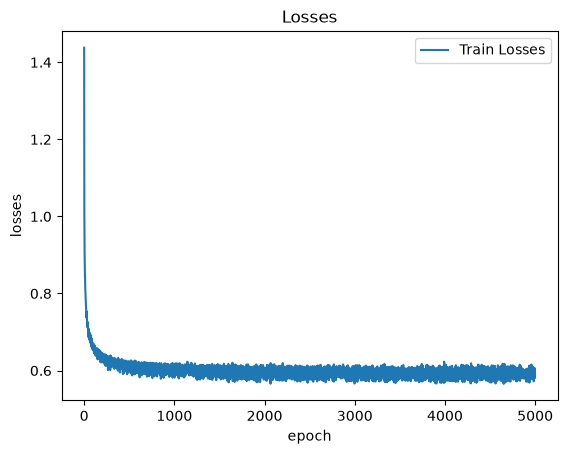

=========Classification report (sklearn, for reference)=======
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       369
           1       0.59      0.63      0.61       317
           2       0.63      0.57      0.60       340
           3       0.83      0.84      0.84       340

    accuracy                           0.73      1366
   macro avg       0.72      0.73      0.72      1366
weighted avg       0.73      0.73      0.73      1366



In [46]:
model_smoke = LogisticRegression(k, n, "minibatch")
model_smoke.fit(X_train_final_np, Y_train_encoded)
yhat = model_smoke.predict(X_test_final_np)
model_smoke.plot()
plt.show()

print("=========Classification report (sklearn, for reference)=======")
print(classification_report(y_test_np, yhat))

## Task 1: Classification metrics from scratch

Each metric is a method of the class. For a class c:

- **precision** = TP / (TP + FP): of the cars predicted as class c, how many really are class c
- **recall** = TP / (TP + FN): of the cars that really are class c, how many the model found
- **F1** = 2 x precision x recall / (precision + recall)
- **macro average**: the plain average over the 4 classes
- **weighted average**: each class weighted by its share of the true labels (support / total)

**Note on the weighted average:** the example in the assignment divides the weighted sum by 4. The weights (0.2 + 0.3 + 0.2 + 0.3) already add up to 1, so dividing again would make the result 4 times too small and it would not match sklearn. My implementation leaves out that extra division.

### 1a. Mock data: my implementation vs sklearn

In [47]:
ytrue_mock = np.array([0, 1, 2, 0, 1, 2, 3, 3])
ypred_mock = np.array([0, 2, 1, 0, 0, 2, 3, 2])

print("Accuracy:", model_smoke.accuracy(ytrue_mock, ypred_mock))
print("Precision per class:", model_smoke.precision(ytrue_mock, ypred_mock))
print("Recall per class:", model_smoke.recall(ytrue_mock, ypred_mock))
print("F1 per class:", model_smoke.f1_score(ytrue_mock, ypred_mock))
print("Macro precision / recall / f1:", model_smoke.macro_precision(ytrue_mock, ypred_mock),
      model_smoke.macro_recall(ytrue_mock, ypred_mock), model_smoke.macro_f1(ytrue_mock, ypred_mock))
print("Weighted precision / recall / f1:", model_smoke.weighted_precision(ytrue_mock, ypred_mock),
      model_smoke.weighted_recall(ytrue_mock, ypred_mock), model_smoke.weighted_f1(ytrue_mock, ypred_mock))

print("\n=== Mine ===")
print(model_smoke.classification_report(ytrue_mock, ypred_mock).round(2))
print("\n=== sklearn reference ===")
print(classification_report(ytrue_mock, ypred_mock, zero_division=0))

Accuracy: 0.5
Precision per class: [0.66666667 0.         0.33333333 1.        ]
Recall per class: [1.  0.  0.5 0.5]
F1 per class: [0.8        0.         0.4        0.66666667]
Macro precision / recall / f1: 0.5 0.5 0.4666666666666667
Weighted precision / recall / f1: 0.5 0.5 0.4666666666666667

=== Mine ===
              precision  recall  f1-score  support
0                  0.67     1.0      0.80        2
1                  0.00     0.0      0.00        2
2                  0.33     0.5      0.40        2
3                  1.00     0.5      0.67        2
accuracy            NaN     NaN      0.50        8
macro avg          0.50     0.5      0.47        8
weighted avg       0.50     0.5      0.47        8

=== sklearn reference ===
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         2
           2       0.33      0.50      0.40         2
           3       1.00      0.50     

### 1b. A larger mock set and the real test predictions, checked number by number

In [48]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compare_with_sklearn(clf, ytrue, ypred, label):
    """Put my numbers next to sklearn's and check they agree."""
    mine = clf.classification_report(ytrue, ypred)
    p, r, f, s = precision_recall_fscore_support(ytrue, ypred, labels=range(clf.k), zero_division=0)
    checks = {
        "per-class precision": np.allclose(mine.loc[[str(c) for c in range(clf.k)], "precision"], p),
        "per-class recall":    np.allclose(mine.loc[[str(c) for c in range(clf.k)], "recall"], r),
        "per-class f1":        np.allclose(mine.loc[[str(c) for c in range(clf.k)], "f1-score"], f),
        "support":             np.array_equal(clf.support(ytrue), s),
        "accuracy":            np.isclose(clf.accuracy(ytrue, ypred), accuracy_score(ytrue, ypred)),
    }
    for avg in ["macro", "weighted"]:
        sk = precision_recall_fscore_support(ytrue, ypred, average=avg, zero_division=0)[:3]
        ours = [getattr(clf, f"{avg}_{m}")(ytrue, ypred) for m in ["precision", "recall", "f1"]]
        checks[f"{avg} avg"] = np.allclose(sk, ours)
    print(f"--- {label} ---")
    for name, ok in checks.items():
        print(f"  {name:<20} {'match' if ok else 'MISMATCH'}")
    return mine

rng = np.random.default_rng(1)
ytrue_big = rng.integers(0, 4, 500)
ypred_big = np.where(rng.random(500) < 0.6, ytrue_big, rng.integers(0, 4, 500))   # ~60% correct

compare_with_sklearn(model_smoke, ytrue_big, ypred_big, "500-row mock data")
compare_with_sklearn(model_smoke, y_test_np, yhat, "real test set (smoke-test model)").round(4)

--- 500-row mock data ---
  per-class precision  match
  per-class recall     match
  per-class f1         match
  support              match
  accuracy             match
  macro avg            match
  weighted avg         match
--- real test set (smoke-test model) ---
  per-class precision  match
  per-class recall     match
  per-class f1         match
  support              match
  accuracy             match
  macro avg            match
  weighted avg         match


,precision,recall,f1-score,support
0,0.8449,0.8564,0.8506,369
1,0.5894,0.6341,0.6109,317
2,0.6307,0.5676,0.5975,340
3,0.8319,0.8441,0.8380,340
accuracy,NaN,NaN,0.7299,1366
macro avg,0.7242,0.7256,0.7243,1366
weighted avg,0.7291,0.7299,0.7288,1366


### What does *support* mean in the classification report?

**Support is the number of samples whose true label is that class**, counted from `y_true`, not from the predictions. It shows how many examples each per-class score is based on (a precision computed from 5 cars is less reliable than one from 500). It is also the weight used in the weighted averages. On the accuracy / macro / weighted rows, support is the total number of samples.

## Task 2: Ridge (L2) penalty

In [49]:
ridge_rows = []
for pen, lam in [(None, 0.0), ("ridge", 0.01), ("ridge", 0.1), ("ridge", 1.0), ("ridge", 10.0)]:
    clf = LogisticRegression(k, n, "batch", alpha=0.0001, max_iter=3000,
                             penalty=pen, lambda_=lam, verbose=False)
    clf.fit(X_train_final_np, Y_train_encoded)
    p = clf.predict(X_test_final_np)
    ridge_rows.append({
        "penalty": pen or "none", "lambda": lam,
        "test_accuracy": clf.accuracy(y_test_np, p),
        "test_macro_f1": clf.macro_f1(y_test_np, p),
        "sum |W| (no bias)": np.abs(clf.W[1:]).sum(),
    })

pd.DataFrame(ridge_rows).round(4)

,penalty,lambda,test_accuracy,test_macro_f1,sum |W| (no bias)
0,none,0.00,0.7240,0.7192,123.7081
1,ridge,0.01,0.7240,0.7192,123.2536
2,ridge,0.10,0.7240,0.7193,119.2726
3,ridge,1.00,0.7247,0.7199,89.4103
4,ridge,10.00,0.7313,0.7248,35.9521


**Observation:** as λ increases, the total size of the weights goes down: from about 124 with no penalty, to 89 at λ = 1 and 36 at λ = 10. Accuracy stays at 0.724 up to λ = 1 and goes up slightly to 0.731 at λ = 10 (macro F1 from 0.719 to 0.725).

So the penalty does what it is supposed to do and shrinks the weights. Small values of λ barely change anything here, because the data part of the loss is a sum over 5461 rows and is much bigger than the penalty term. The small gain at λ = 10 suggests the model without a penalty overfits a little, but the difference is small, so I would not read too much into it.

## Task 3: Experiments with MLflow, model registry and deployment

**About the MLflow server:** the course MLflow server was unstable during this assignment. Following the TA announcement on 1 October 2026, Objectives 1 and 2 were done on a local MLflow server (`http://localhost:5000`), the same way as in A2, and screenshots of the runs and the registered model are included below. The code can still log to the course server: setting `USE_CSIM_SERVER = True` in the next cell switches to `https://mlflow.ml.brain.cs.ait.ac.th` and asks for the shared password.

Setup:

- Experiment name: `st126979-a3`
- Registered model: `st126979-a3-model`, moved to Staging
- Each run saves the trained model together with its preprocessing (encoder, scaler and column order). The dataset itself is not logged.
- To choose the settings I split the training set again into training and validation (80/20). The test set is only used once, on the final model.

In [50]:
import getpass
import mlflow
import mlflow.pyfunc

# ---- Which MLflow server to log to ----
USE_CSIM_SERVER = False       # False = local MLflow (http://localhost:5000), used for the submitted runs

LOCAL_URI = "http://localhost:5000"
CSIM_URI  = "https://mlflow.ml.brain.cs.ait.ac.th"

if USE_CSIM_SERVER:
    # Shared class account from the TA. The password is typed in, not stored in the notebook.
    os.environ["MLFLOW_TRACKING_USERNAME"] = "student"
    if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
        os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass.getpass("MLflow password: ")

mlflow.set_tracking_uri(CSIM_URI if USE_CSIM_SERVER else LOCAL_URI)
os.environ["LOGNAME"] = "st126979"              # tags each run with my student ID

EXPERIMENT_NAME = "st126979-a3"
MODEL_NAME = "st126979-a3-model"
EXPERIMENT_MODEL_CODE = ["app/code/model.py"]   # copied into every logged model so it can be loaded anywhere

experiment = mlflow.set_experiment(EXPERIMENT_NAME)
print("Tracking URI :", mlflow.get_tracking_uri())
print("Experiment   :", experiment.name, "| id", experiment.experiment_id)
print("model.py found:", os.path.exists(EXPERIMENT_MODEL_CODE[0]))

Tracking URI : http://localhost:5000
Experiment   : st126979-a3 | id 3
model.py found: True


### 3a. Validation split

In [51]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final_np, y_train_np, test_size=0.2, random_state=42, stratify=y_train_np)
Y_tr = np.eye(k)[y_tr]      # one-hot, same as Y_train_encoded
print(X_tr.shape, X_val.shape)

(4368, 42) (1093, 42)


### 3b. Experiment grid (27 runs)

3 methods x 3 learning rates x 3 penalty settings (no penalty, ridge λ = 0.1, ridge λ = 1.0). Each run logs its parameters, the validation accuracy, macro F1 and weighted F1, the final training loss, and the model.

In [52]:
methods = ["batch", "minibatch", "sto"]
learning_rates = [0.01, 0.001, 0.0001]
penalties = [(None, 0.0), ("ridge", 0.1), ("ridge", 1.0)]
MAX_ITER = 5000

results = []
mlflow.end_run()   # make sure no half-finished run from an earlier error is still open

for method, lr, (pen, lam) in itertools.product(methods, learning_rates, penalties):
    run_name = f"{method}-lr{lr}-{pen or 'none'}{'' if pen is None else f'-l{lam}'}"
    with mlflow.start_run(run_name=run_name) as run:
        clf = LogisticRegression(k, n, method, alpha=lr, max_iter=MAX_ITER,
                                 penalty=pen, lambda_=lam, verbose=False)
        clf.fit(X_tr, Y_tr)
        p = clf.predict(X_val)

        params = {"method": method, "learning_rate": lr, "penalty": str(pen),
                  "lambda": lam, "max_iter": MAX_ITER}
        metrics = {"val_accuracy": clf.accuracy(y_val, p),
                   "val_macro_f1": clf.macro_f1(y_val, p),
                   "val_weighted_f1": clf.weighted_f1(y_val, p),
                   "final_train_loss": float(clf.losses[-1])}
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)

        # Save the model (with its preprocessing) , no dataset is logged
        mlflow.pyfunc.log_model(
            name="model",          # MLflow 3 name for the logged model (was artifact_path)
            python_model=CarPriceClassifier(clf, encoder, scaler, numeric_cols,
                                            categorical_cols, feature_names, price_bins),
            code_paths=EXPERIMENT_MODEL_CODE,
        )
        results.append({"run_name": run_name, "run_id": run.info.run_id, **params, **metrics})
        print(f"{run_name:<32} val_acc={metrics['val_accuracy']:.4f}  val_macro_f1={metrics['val_macro_f1']:.4f}")

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
results_df.drop(columns=["run_id"]).head(10).round(4)

2026/10/04 13:39:09 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


batch-lr0.01-none                val_acc=0.6221  val_macro_f1=0.6044
🏃 View run batch-lr0.01-none at: http://localhost:5000/#/experiments/3/runs/34cc293244794855ab1ab0283e286be3
🧪 View experiment at: http://localhost:5000/#/experiments/3


2026/10/04 13:39:12 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


batch-lr0.01-ridge-l0.1          val_acc=0.5993  val_macro_f1=0.5812
🏃 View run batch-lr0.01-ridge-l0.1 at: http://localhost:5000/#/experiments/3/runs/48f71745886d4a569bb337796c54c157
🧪 View experiment at: http://localhost:5000/#/experiments/3


2026/10/04 13:39:15 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


...

2026/10/04 13:40:01 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


sto-lr0.0001-none                val_acc=0.3788  val_macro_f1=0.3837
🏃 View run sto-lr0.0001-none at: http://localhost:5000/#/experiments/3/runs/750abef3720a49e0899f5a08acf76cfb
🧪 View experiment at: http://localhost:5000/#/experiments/3


2026/10/04 13:40:03 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


sto-lr0.0001-ridge-l0.1          val_acc=0.3788  val_macro_f1=0.3834
🏃 View run sto-lr0.0001-ridge-l0.1 at: http://localhost:5000/#/experiments/3/runs/fd528aa779ac41199cf37f156a9e7b12
🧪 View experiment at: http://localhost:5000/#/experiments/3
sto-lr0.0001-ridge-l1.0          val_acc=0.3550  val_macro_f1=0.3514
🏃 View run sto-lr0.0001-ridge-l1.0 at: http://localhost:5000/#/experiments/3/runs/ee459f35f2fd4c148c2452d9e7863138
🧪 View experiment at: http://localhost:5000/#/experiments/3


,run_name,method,learning_rate,penalty,lambda,max_iter,val_accuracy,val_macro_f1,val_weighted_f1,final_train_loss
0,batch-lr0.0001-ridge-l0.1,batch,0.0001,ridge,0.1,5000,0.7429,0.7406,0.7451,0.6088
1,minibatch-lr0.001-ridge-l0.1,minibatch,0.0010,ridge,0.1,5000,0.7420,0.7401,0.7444,0.6176
2,minibatch-lr0.001-none,minibatch,0.0010,None,0.0,5000,0.7420,0.7400,0.7444,0.6016
3,batch-lr0.0001-ridge-l1.0,batch,0.0001,ridge,1.0,5000,0.7420,0.7399,0.7443,0.6382
4,batch-lr0.0001-none,batch,0.0001,None,0.0,5000,0.7420,0.7397,0.7441,0.6037
5,minibatch-lr0.0001-none,minibatch,0.0001,None,0.0,5000,0.7264,0.7239,0.7286,0.6218
6,minibatch-lr0.001-ridge-l1.0,minibatch,0.0010,ridge,1.0,5000,0.7264,0.7233,0.7280,0.6780
7,minibatch-lr0.0001-ridge-l0.1,minibatch,0.0001,ridge,0.1,5000,0.7255,0.7228,0.7275,0.6324
8,minibatch-lr0.0001-ridge-l1.0,minibatch,0.0001,ridge,1.0,5000,0.7210,0.7168,0.7217,0.6847
9,batch-lr0.001-none,batch,0.0010,None,0.0,5000,0.7200,0.7152,0.7197,0.6425


### 3c. Comparison views

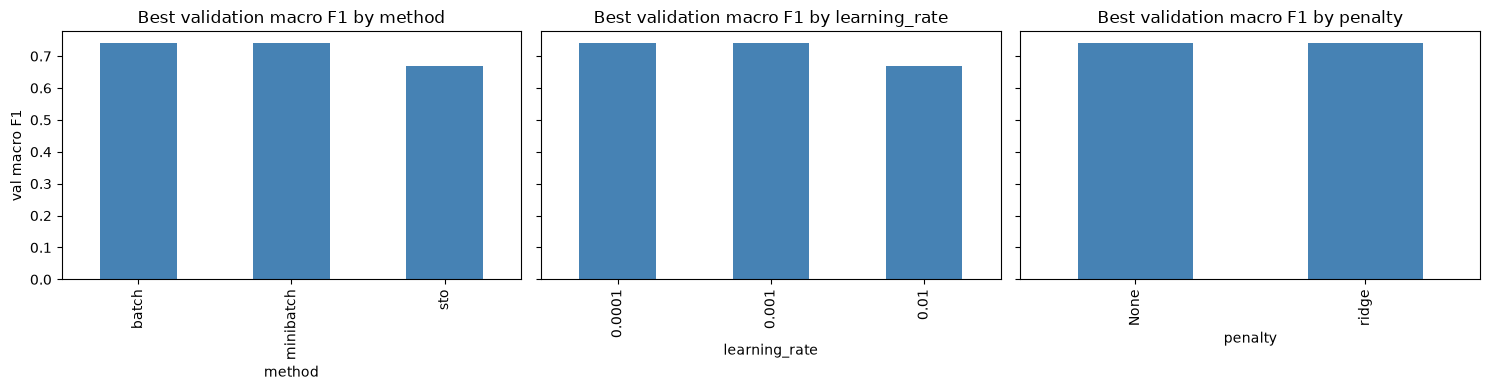

penalty                    None   ridge
method    learning_rate                
batch     0.0001         0.7397  0.7406
          0.0010         0.7152  0.7031
          0.0100         0.6044  0.5812
minibatch 0.0001         0.7239  0.7228
          0.0010         0.7400  0.7401
          0.0100         0.6157  0.5995
sto       0.0001         0.3837  0.3834
          0.0010         0.5524  0.5741
          0.0100         0.6683  0.4698

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col in zip(axes, ["method", "learning_rate", "penalty"]):
    results_df.groupby(col)["val_macro_f1"].max().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Best validation macro F1 by {col}")
    ax.set_xlabel(col)
axes[0].set_ylabel("val macro F1")
plt.tight_layout()
plt.show()

results_df.pivot_table(index=["method", "learning_rate"], columns="penalty",
                       values="val_macro_f1", aggfunc="max").round(4)

#### What the experiments show

Looking at the validation macro F1 of the 27 runs:

- **The learning rate mattered the most.** With 0.01 every method did badly (0.33 to 0.67). The gradient in this class is a sum over the batch, not an average, so with thousands of rows a step size of 0.01 is far too large and the weights keep jumping around instead of settling.
- **The best learning rate depends on the method.** Batch did best with 0.0001 (0.740) and mini-batch with 0.001 (0.740). A mini-batch only uses 30% of the rows, so its gradient is smaller and it can handle a larger learning rate.
- **Stochastic gradient descent was the weakest.** 5000 steps with one row each is only about one pass over the 4368 training rows. With 0.0001 it barely moved away from the random starting weights (0.38), and with 0.01 it reached 0.67 but the loss was very noisy.
- **Ridge made almost no difference.** For the good settings, the runs with and without the penalty were within 0.001 of each other. With a large learning rate, λ = 1.0 made the results worse.

The best run was batch gradient descent, learning rate 0.0001, ridge λ = 0.1 (validation macro F1 0.7406). The top five runs are all between 0.7397 and 0.7406, so the choice between them is basically a tie.

### 3d. Retrain the best configuration on the full training set and evaluate on the test set

Best configuration:
 method              batch
learning_rate      0.0001
penalty             ridge
lambda                0.1
val_macro_f1     0.740644
Name: 0, dtype: object


2026/10/04 13:40:06 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run final-best at: http://localhost:5000/#/experiments/3/runs/656fd9c42d8443c09867481b25aa0a5b
🧪 View experiment at: http://localhost:5000/#/experiments/3


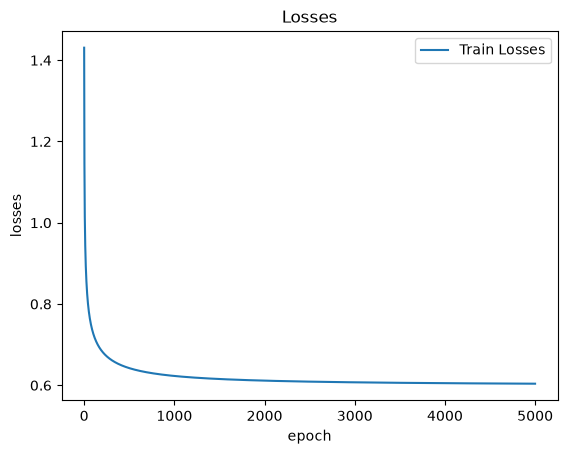

              precision  recall  f1-score  support
0                0.8529  0.8482    0.8505      369
1                0.5788  0.6372    0.6066      317
2                0.6181  0.5618    0.5886      340
3                0.8299  0.8324    0.8311      340
accuracy            NaN     NaN    0.7240     1366
macro avg        0.7199  0.7199    0.7192     1366
weighted avg     0.7251  0.7240    0.7239     1366


In [54]:
best = results_df.iloc[0]
best_pen = None if best["penalty"] == "None" else best["penalty"]
print("Best configuration:\n", best[["method", "learning_rate", "penalty", "lambda", "val_macro_f1"]])

with mlflow.start_run(run_name="final-best") as run:
    final_model = LogisticRegression(k, n, best["method"], alpha=best["learning_rate"],
                                     max_iter=MAX_ITER, penalty=best_pen,
                                     lambda_=best["lambda"], verbose=False)
    final_model.fit(X_train_final_np, Y_train_encoded)
    y_pred_test = final_model.predict(X_test_final_np)

    mlflow.log_params({"method": best["method"], "learning_rate": best["learning_rate"],
                       "penalty": str(best_pen), "lambda": best["lambda"], "max_iter": MAX_ITER})
    mlflow.log_metrics({"test_accuracy": final_model.accuracy(y_test_np, y_pred_test),
                        "test_macro_f1": final_model.macro_f1(y_test_np, y_pred_test),
                        "test_weighted_f1": final_model.weighted_f1(y_test_np, y_pred_test)})

    final_wrapped = CarPriceClassifier(final_model, encoder, scaler, numeric_cols,
                                       categorical_cols, feature_names, price_bins)
    model_info = mlflow.pyfunc.log_model(name="model", python_model=final_wrapped,
                                         code_paths=EXPERIMENT_MODEL_CODE)
    final_run_id = run.info.run_id
    final_model_uri = model_info.model_uri     # exact address of this logged model, used to register it

final_model.plot()
plt.show()
print(final_model.classification_report(y_test_np, y_pred_test).round(4))

#### Final model on the test set

On the 1366 test cars the final model gets **0.724 accuracy, 0.719 macro F1 and 0.724 weighted F1**.

- Class 0 (cheapest) and class 3 (most expensive) are predicted well, with F1 of 0.85 and 0.83.
- Classes 1 and 2 are much harder, with F1 of 0.61 and 0.59. Their price ranges are narrow (250,000 to 410,000 and 410,000 to 640,000), and cars just above and below a boundary look very similar in year, power and brand.
- Almost all mistakes are between neighbouring classes. Out of 377 wrong predictions, only 10 are more than one class away from the true class.
- The smoke test model (mini-batch, 0.001) scored 0.730 on the test set, slightly higher than this model. The gap is small, and the final model was picked using the validation set, not the test set, so I kept the validation choice.

### 3e. Save a copy for the web app and CI tests

In [55]:
with open("app/code/model/a3_model.pkl", "wb") as f:
    pickle.dump(final_wrapped, f)

# Sanity check: raw rows in, the same predictions out
with open("app/code/model/a3_model.pkl", "rb") as f:
    reloaded = pickle.load(f)
print("Reloaded predictions match:",
      np.array_equal(reloaded.predict(None, X_test), final_model.predict(X_test_final_np)))

Reloaded predictions match: True


### 3f. Register the best model and move it to Staging

Registered name: `st126979-a3-model`. It is registered straight from the `final-best` run's logged model (`final_model_uri`), then moved to **Staging**. Each re-run adds a new version; the newest one is put in Staging.

In the UI the same thing is: Experiment `st126979-a3` → `final-best` run → logged model → **Register model** → Models → `st126979-a3-model` → version → Stage: **Staging**.

If the server's MLflow no longer supports stages, the `except` branch sets the alias `staging` instead.

In [56]:
client = mlflow.MlflowClient()
mv = mlflow.register_model(final_model_uri, MODEL_NAME)
print(f"Registered {MODEL_NAME}, version {mv.version}")

try:
    client.transition_model_version_stage(MODEL_NAME, mv.version, stage="Staging",
                                          archive_existing_versions=True)   # older versions leave Staging
    staged_uri = f"models:/{MODEL_NAME}/Staging"
except Exception as e:
    print("Stages not supported, using alias instead:", e)
    client.set_registered_model_alias(MODEL_NAME, "staging", mv.version)
    staged_uri = f"models:/{MODEL_NAME}@staging"

# Load it back from the registry and check it gives the same answers as the trained model
staged = mlflow.pyfunc.load_model(staged_uri)
registry_pred = np.asarray(staged.predict(X_test.head()))
print("Loaded from registry:", staged_uri)
print("Predictions for 5 test cars:", registry_pred)
print("True classes              :", y_test.head().to_numpy())
print("Same as the trained model :", np.array_equal(registry_pred, final_model.predict(X_test_final_np[:5])))

Registered model 'st126979-a3-model' already exists. Creating a new version of this model...
2026/10/04 13:40:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: st126979-a3-model, version 5


Registered st126979-a3-model, version 5


Created version '5' of model 'st126979-a3-model'.
/var/folders/yw/tf6z42fj6n57b4jbb4vxjz0r0000gn/T/ipykernel_8108/2340416726.py:6: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(MODEL_NAME, mv.version, stage="Staging",


Loaded from registry: models:/st126979-a3-model/Staging
Predictions for 5 test cars: [0 0 0 3 0]
True classes              : [0 0 0 2 0]
Same as the trained model : True


### MLflow screenshots

Screenshots from the local MLflow UI (`http://localhost:5000`).

**Experiment runs (`st126979-a3`)**

![MLflow experiment runs](screenshots/mlflow_runs.png)

**Best run (`final-best`) with its parameters and metrics**

![MLflow final-best run](screenshots/mlflow_best_run.png)


## Deployment and CI/CD

### Files involved

| File | What it does |
| --- | --- |
| `app/code/app.py` | the Dash app with the A1 and A2 pages and the new A3 "Price class" page |
| `app/code/model.py` | the `LogisticRegression` class and the `CarPriceClassifier` wrapper (written by section 9) |
| `app/code/model/a3_model.pkl` | the final model saved in section 3e, loaded by the app |
| `app/code/test_model.py` | the two unit tests |
| `app/Dockerfile`, `app/requirements.txt` | build the Docker image for the app |
| `.github/workflows/ci-cd.yml` | the GitHub Actions pipeline |

### Unit tests

`app/code/test_model.py` has the two tests asked for in the assignment:

1. `test_model_takes_expected_input`: a raw car row (the same format the web form sends) goes through the preprocessing and comes out as one row with the intercept plus every feature the model was trained on, and the prediction runs without errors.
2. `test_output_has_expected_shape`: 5 rows in gives 5 predictions out, and every prediction is one of the classes 0, 1, 2 or 3.

### GitHub Actions pipeline

The workflow runs on every push to `main` and has three jobs. Each job only starts if the one before it passed.

1. **test:** installs `app/requirements.txt` and runs `pytest app/code`.
2. **build-and-push:** builds the Docker image from `app/` and pushes it to Docker Hub as `barnnitash/car-price-app:a3`.
3. **deploy:** connects to ml-brain over SSH through the bazooka jump host and runs `docker compose pull` and `docker compose up -d` in `~/st126979-app`, so the server always runs the newest image.

The Docker Hub login, the SSH key and the jump host are stored as GitHub secrets, not in the code.

### Problems I ran into

- numpy, pandas and scikit-learn are pinned in `requirements.txt` to the versions I trained with, so the saved model loads the same way inside Docker.
- The Traefik reverse proxy and its `traefik_default` network were not running on ml-brain, so the subdomain setup from A2 did not work. Like other students, I published the app directly on a port instead (8979): http://ml.brain.cs.ait.ac.th:8979

### Screenshots

**All three jobs passing**

![CI/CD pipeline passing](screenshots/deploy_success.png)

**The deployed web app**

![Deployed web app](screenshots/deployed_app.png)

## Report

**1. Target classes.** I split `selling_price` into four classes using quantiles (`pd.qcut`), so each class has roughly a quarter of the 6827 cars (1846, 1583, 1697 and 1701). The price ranges are 30,000 to 250,000, 250,000 to 410,000, 410,000 to 640,000 and 640,000 to 10,000,000. I chose quantiles because the price is very right-skewed, and equal-width bins would have put almost every car in class 0.

**2. Metrics from scratch.** Accuracy, per-class precision, recall and F1, and the macro and weighted averages all match sklearn's `classification_report`, both on mock data and on the real test predictions. The only difference from the assignment's formula is that the weighted average is not divided by 4 again, because the class weights already add up to 1.

**3. Ridge.** The penalty shrinks the weights as λ grows (total weight size drops from about 124 to 36 at λ = 10), but it hardly changes the accuracy. With this many rows the data term is much larger than the penalty, so only a large λ has a visible effect.

**4. Experiments.** The learning rate had the biggest effect. 0.01 was too large for all three methods, and stochastic gradient descent with 0.0001 barely trained in 5000 steps. Batch with 0.0001 and mini-batch with 0.001 gave the best results, around 0.74 validation macro F1. Adding ridge changed the result by less than 0.001 for these settings. The chosen model is batch gradient descent with learning rate 0.0001 and ridge λ = 0.1.

**5. Final model.** On the test set it gets 0.724 accuracy and 0.719 macro F1. The cheapest and the most expensive classes are easy (F1 0.85 and 0.83), while the two middle classes are harder (0.61 and 0.59). Only 10 of the 377 wrong predictions are more than one class away from the true class, so the model almost always gets the price range right or misses it by one.

**6. Deployment.** The web app now has a third page for the price class model next to the A1 and A2 pages. Every push to GitHub runs the unit tests, builds and pushes the Docker image, and redeploys it on ml-brain. The app runs at http://ml.brain.cs.ait.ac.th:8979.